# Chapter 5: Resampling Methods Q 3 and Q 8 

## Q 3: K-Fold Cross-Validation

### (a) How is k-fold cross-validation implemented?

1. Randomly divide the n observations into k approximately equal-sized folds.
2. For each fold, use the other k−1 folds for training and the selected fold for validation.
3. Fit the model on the training data and calculate its prediction error on the validation fold.
4. Repeat this process until every fold has served as the validation set.
5. Average the k validation errors. For MSE:

$$CV_k = \\frac{1}{k}\\sum_{j=1}^{k}MSE_j$$

The result estimates the model's test prediction error.

### (b) Advantages and disadvantages

#### (i) Compared with the validation set approach

**Advantages:**
- Uses the observations more efficiently because every observation is used for validation once and training k−1 times.
- Usually gives a more stable estimate than relying on one random train/validation split.
- Each fitted model uses a large proportion of the available data.

**Disadvantages:**
- More computationally expensive because the model is fitted k times.
- The fitted models share many training observations, so they are not independent.

#### (ii) Compared with LOOCV

**Advantages:**
- Much less computationally expensive when k is 5 or 10 instead of n.
- Often has lower variance than LOOCV because the validation sets contain multiple observations.
- k=5 or k=10 provides a practical balance between bias, variance, and computation.

**Disadvantages:**
- There is slightly more bias because each model is trained on only (k−1)/k of the observations rather than n−1.
- The result can depend somewhat on how observations are assigned to folds, although repeated k-fold CV can reduce this issue.

# Q8
## a. Generate the simulated data

The data are generated using:

```python
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
```

**n = 100**, because there are 100 observations.

**p = 1**, because there is one predictor, X. The powers X², X³ and X⁴ are transformations of that predictor.

The data-generating model is:

$$Y = X - 2X^2 + \\epsilon$$

where $X \\sim N(0,1)$ and $\\epsilon \\sim N(0,1)$.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats

rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = len(x)
p = 1
df = pd.DataFrame({'X': x, 'Y': y})

print('n =', n)
print('p =', p)
df.head()

n = 100
p = 1


,X,Y
0,0.345584,-0.544554
1,0.821618,0.333950
2,0.330437,-0.013532
3,-1.303157,-4.030442
4,0.905356,0.484861


## b. Scatterplot

The scatterplot shows a clear **nonlinear, downward-opening parabolic relationship**. A straight-line model will therefore miss important structure in the data. The shape strongly suggests that a quadratic term $X^2$ is needed.

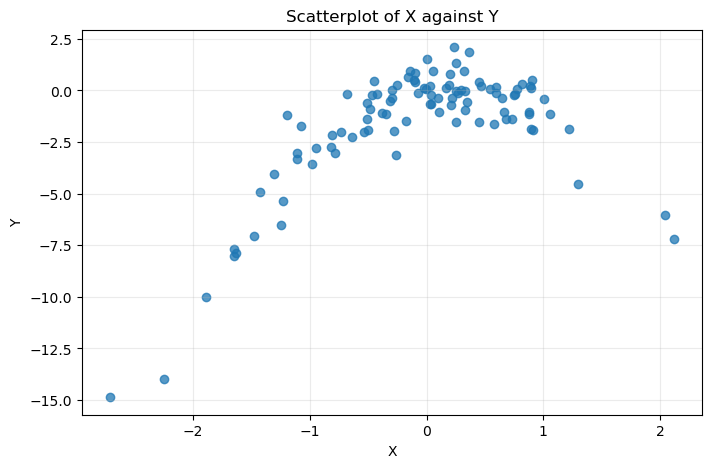

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.75)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X against Y')
plt.grid(alpha=0.25)
plt.show()

## c. LOOCV errors

Four polynomial least-squares models are evaluated:

1. $Y = \\beta_0 + \\beta_1X + \\epsilon$
2. $Y = \\beta_0 + \\beta_1X + \\beta_2X^2 + \\epsilon$
3. $Y = \\beta_0 + \\beta_1X + \\beta_2X^2 + \\beta_3X^3 + \\epsilon$
4. $Y = \\beta_0 + \\beta_1X + \\beta_2X^2 + \\beta_3X^3 + \\beta_4X^4 + \\epsilon$

In [14]:
def loocv_mse(degree, seed):
    rng_local = np.random.default_rng(seed)
    indices = rng_local.permutation(len(x))
    errors = []

    for pos, test_idx in enumerate(indices):
        train_idx = np.delete(indices, pos)
        X_train = np.column_stack([x[train_idx] ** d for d in range(1, degree + 1)])
        X_test = np.array([[x[test_idx] ** d for d in range(1, degree + 1)]])

        model = LinearRegression()
        model.fit(X_train, y[train_idx])
        prediction = model.predict(X_test)[0]
        errors.append((y[test_idx] - prediction) ** 2)

    return np.mean(errors)

seed = 1
results = {degree: loocv_mse(degree, seed) for degree in range(1, 5)}

for degree, mse in results.items():
    print(f'Model degree {degree}: LOOCV MSE = {mse:.6f}')

Model degree 1: LOOCV MSE = 6.633030
Model degree 2: LOOCV MSE = 1.122937
Model degree 3: LOOCV MSE = 1.301797
Model degree 4: LOOCV MSE = 1.332394


## d. Repeat with another random seed

A different seed changes only the order in which the LOOCV observations are processed. Every observation is still left out exactly once. Therefore, ordinary LOOCV produces the same final average MSE (up to numerical rounding).

In [17]:
seed1 = 1
seed2 = 42

cv1 = {d: loocv_mse(d, seed1) for d in range(1, 5)}
cv2 = {d: loocv_mse(d, seed2) for d in range(1, 5)}

comparison = pd.DataFrame({
    'Model': ['i. Linear', 'ii. Quadratic', 'iii. Cubic', 'iv. Quartic'],
    'Seed 1': [cv1[d] for d in range(1, 5)],
    'Seed 42': [cv2[d] for d in range(1, 5)]
})
comparison['Difference'] = comparison['Seed 42'] - comparison['Seed 1']
comparison

,Model,Seed 1,Seed 42,Difference
0,i. Linear,6.633030,6.633030,1.776357e-15
1,ii. Quadratic,1.122937,1.122937,0.000000e+00
2,iii. Cubic,1.301797,1.301797,2.220446e-16
3,iv. Quartic,1.332394,1.332394,1.554312e-15


## e. Which model has the smallest LOOCV error?

The model with the smallest LOOCV error is preferred because it has the best estimated prediction performance on unseen observations.

The quadratic model is expected to perform best because the true data-generating process contains the term $-2X^2$. Extra cubic and quartic terms are not part of the true model and may add unnecessary flexibility.

In [20]:
best_degree = min(cv1, key=cv1.get)
print('Best model degree:', best_degree)
print('Smallest LOOCV MSE:', cv1[best_degree])

Best model degree: 2
Smallest LOOCV MSE: 1.1229368563419684


## f. Statistical significance of coefficients

We use ordinary least squares to calculate coefficient estimates, standard errors, t-statistics, and p-values.

Because the true model is $Y = X - 2X^2 + \\epsilon$, the coefficients of X and X² should be statistically significant. The additional X³ and X⁴ terms are not part of the true model, so they are not expected to be significant.

This generally agrees with cross-validation: the quadratic model captures the important nonlinear relationship, whereas higher-order terms provide little additional predictive benefit.

In [23]:
def ols_summary(degree):
    X = np.column_stack([x**d for d in range(1, degree + 1)])
    X_design = np.column_stack([np.ones(len(x)), X])

    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    residuals = y - X_design @ beta
    df_resid = len(y) - X_design.shape[1]
    mse = np.sum(residuals**2) / df_resid
    cov_beta = mse * np.linalg.inv(X_design.T @ X_design)
    se = np.sqrt(np.diag(cov_beta))
    t_values = beta / se
    p_values = 2 * stats.t.sf(np.abs(t_values), df_resid)

    names = ['Intercept'] + ['X' if d == 1 else f'X^{d}' for d in range(1, degree + 1)]

    return pd.DataFrame({
        'Coefficient': names,
        'Estimate': beta,
        'Std_Error': se,
        't_value': t_values,
        'p_value': p_values,
        'Significant_0.05': p_values < 0.05
    })

for degree in range(1, 5):
    print(f'\\nModel degree {degree}')
    display(ols_summary(degree).round(6))

\nModel degree 1


,Coefficient,Estimate,Std_Error,t_value,p_value,Significant_0.05
0,Intercept,-1.464963,0.246753,-5.936971,0.0,True
1,X,1.949369,0.288690,6.752466,0.0,True


\nModel degree 2


,Coefficient,Estimate,Std_Error,t_value,p_value,Significant_0.05
0,Intercept,-0.072755,0.119134,-0.610703,0.542824,False
1,X,0.966273,0.126353,7.647396,0.000000,True
2,X^2,-2.004709,0.090826,-22.072018,0.000000,True


\nModel degree 3


,Coefficient,Estimate,Std_Error,t_value,p_value,Significant_0.05
0,Intercept,-0.057197,0.119929,-0.476922,0.634502,False
1,X,1.114584,0.187472,5.945351,0.000000,True
2,X^2,-2.047094,0.099022,-20.673057,0.000000,True
3,X^3,-0.064300,0.060081,-1.070224,0.287202,False


\nModel degree 4


,Coefficient,Estimate,Std_Error,t_value,p_value,Significant_0.05
0,Intercept,0.100848,0.135818,0.742518,0.459605,False
1,X,0.904998,0.204614,4.422961,0.000026,True
2,X^2,-2.505923,0.221058,-11.336054,0.000000,True
3,X^3,0.033768,0.072510,0.465707,0.642491,False
4,X^4,0.104217,0.045134,2.309075,0.023107,True
